# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [11]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [12]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    
    B, C, H, W = x.shape
    P = patch_size

    assert H == W
    assert H % P == 0

    h = H//P
    w = W//P

    proto_patches1 = x.reshape((B,C,h,P,w,P))
    proto_patches2 = proto_patches1.permute(0,2,4,1,3,5)
    patches = proto_patches2.reshape(B, h*w, C * P * P)

    return patches

    

In [13]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        self.model = nn.Linear(patch_dim, d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        return self.model(x_patches)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        self.positional_embedding = nn.Embedding(num_tokens, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.positional_embedding(torch.arange(x.shape[1], device=x.device))

#### Comparison Justification
- GEGLU is a natural choice to compare to our baseline (feedforward with GELU), because it isolates the effect of adding the gating mechanism, since it still uses GELU
- SwiGLU is the most widely adopted for LLMs, reportedly being used in Llama 2 and 3 and a wide variety of other large language-models, Thus, it is a natural choice to evaluate. It is, however, further away from our baseline condition using the Swish activation function (x * sigmoid(x)), rather than GELU.

In [14]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff,d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


class GLUFeedForward(nn.Module):
    """GLU-family FFN"""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        activation_functions = {
            "GEGLU": nn.GELU(),
            "SwiGLU": nn.SiLU()
        }
        self.activation = activation_functions[variant]
        self.gated = nn.Sequential(nn.Linear(d_model, d_ff_gated), self.activation)
        self.linear = nn.Sequential(nn.Linear(d_model,d_ff_gated))
        self.output = nn.Sequential(nn.Linear(d_ff_gated,d_model), nn.Dropout(dropout))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.output(self.gated(x) * self.linear(x))

In [15]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model,n_heads,dropout,batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.mlp = mlp
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.dropout(self.attention(self.ln1(x),self.ln1(x), self.ln1(x))[0])
        x = x + self.dropout(self.mlp(self.ln2(x)))
        return x

In [16]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        self.patch_embed = PatchEmbed(patch_dim, d_model)
        self.pos_embed = PositionalEmbedding(self.num_tokens, d_model)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=FeedForward(d_model, d_ff, dropout) if mlp_kind == "baseline" else GLUFeedForward(d_model, 2*d_ff//3, dropout, mlp_kind),
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        self.class_head = nn.Linear(d_model, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = patchify(x, self.patch_size)
        x = self.patch_embed(x)
        x = self.pos_embed(x)
        
        for block in self.blocks:
            x = block(x)

        x = x.mean(dim=1)
        logits = self.class_head(x)

        return logits

In [17]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cpu"  # set "cuda" if available

In [18]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = torch.nn.functional.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        "train_losses": train_losses,
        "test_accs": test_accs,
        "max_acc": torch.max(torch.tensor(test_accs)),
        "final_acc": test_accs[-1],
        "n_params": sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

In [19]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = ["baseline", "GEGLU", "SwiGLU"]
results = []

for kind in runs:
    torch.manual_seed(cfg.seed)
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nRun: {kind} | params: {n_params:,}")
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    results.append(out)
    print(f"Test Accuracies: {out['test_accs']}\nMax Accuracy: {out['max_acc']}\nFinal Accuracy: {out['final_acc']}")


Run: baseline | params: 104,842
[baseline] epoch 1/5 | test acc: 0.8475
[baseline] epoch 2/5 | test acc: 0.9131
[baseline] epoch 3/5 | test acc: 0.9301
[baseline] epoch 4/5 | test acc: 0.9402
[baseline] epoch 5/5 | test acc: 0.9477
Test Accuracies: [0.8475, 0.9131, 0.9301, 0.9402, 0.9477]
Max Accuracy: 0.947700023651123
Final Accuracy: 0.9477

Run: GEGLU | params: 104,754
[GEGLU] epoch 1/5 | test acc: 0.8799
[GEGLU] epoch 2/5 | test acc: 0.9264
[GEGLU] epoch 3/5 | test acc: 0.9436
[GEGLU] epoch 4/5 | test acc: 0.9547
[GEGLU] epoch 5/5 | test acc: 0.9572
Test Accuracies: [0.8799, 0.9264, 0.9436, 0.9547, 0.9572]
Max Accuracy: 0.9571999907493591
Final Accuracy: 0.9572

Run: SwiGLU | params: 104,754
[SwiGLU] epoch 1/5 | test acc: 0.8786
[SwiGLU] epoch 2/5 | test acc: 0.9253
[SwiGLU] epoch 3/5 | test acc: 0.9402
[SwiGLU] epoch 4/5 | test acc: 0.9541
[SwiGLU] epoch 5/5 | test acc: 0.9548
Test Accuracies: [0.8786, 0.9253, 0.9402, 0.9541, 0.9548]
Max Accuracy: 0.954800009727478
Final Accuracy

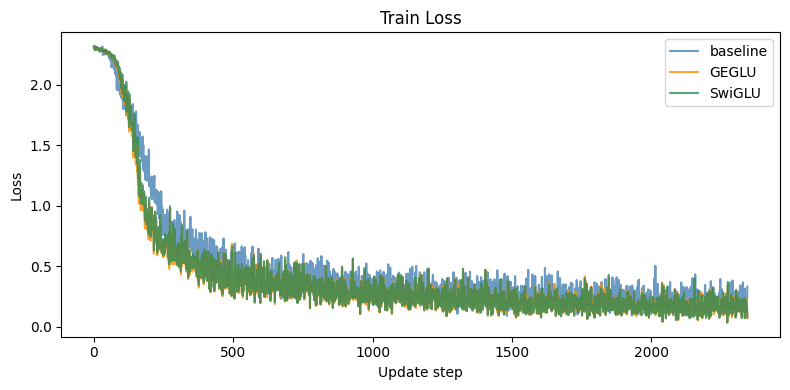

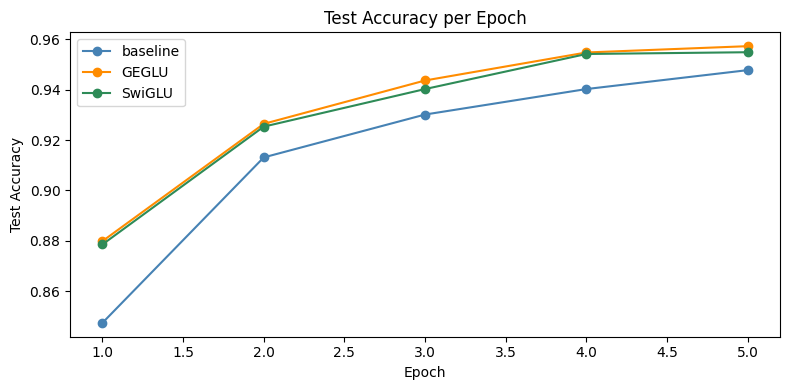

In [ ]:
#import matplotlib.pyplot as plt

variant_names = ["baseline", "GEGLU", "SwiGLU"]
colors = ["steelblue", "darkorange", "seagreen"]

# 1. Train loss curves
plt.figure(figsize=(8, 4))
for result, name, color in zip(results, variant_names, colors):
    plt.plot(result["train_losses"], label=name, color=color, alpha=0.8)
plt.xlabel("Update step")
plt.ylabel("Loss")
plt.title("Train Loss")
plt.legend()
plt.tight_layout()
plt.savefig("train_loss.png", dpi=150)
plt.show()

# 2. Test accuracy per epoch
plt.figure(figsize=(8, 4))
for result, name, color in zip(results, variant_names, colors):
    plt.plot(range(1, len(result["test_accs"]) + 1), result["test_accs"], label=name, color=color, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy per Epoch")
plt.legend()
plt.tight_layout()
plt.savefig("test_accuracy.png", dpi=150)
plt.show()

In [22]:
extra_seeds = [1, 2]
all_results = {kind: [results[i]] for i, kind in enumerate(runs)}  # reuse existing

for kind in runs:
    for seed in extra_seeds:
        torch.manual_seed(seed)
        model = TinyViT(patch_size=patch_size, d_model=d_model, n_heads=n_heads,
                        n_layers=n_layers, d_ff=d_ff, dropout=dropout, mlp_kind=kind)
        out = train_one_run(kind, model, train_loader, test_loader, cfg)
        all_results[kind].append(out)

[baseline] epoch 1/5 | test acc: 0.8105
[baseline] epoch 2/5 | test acc: 0.8954
[baseline] epoch 3/5 | test acc: 0.9215
[baseline] epoch 4/5 | test acc: 0.9362
[baseline] epoch 5/5 | test acc: 0.9452
[baseline] epoch 1/5 | test acc: 0.8116
[baseline] epoch 2/5 | test acc: 0.9034
[baseline] epoch 3/5 | test acc: 0.9259
[baseline] epoch 4/5 | test acc: 0.9390
[baseline] epoch 5/5 | test acc: 0.9448
[GEGLU] epoch 1/5 | test acc: 0.8854
[GEGLU] epoch 2/5 | test acc: 0.9307
[GEGLU] epoch 3/5 | test acc: 0.9488
[GEGLU] epoch 4/5 | test acc: 0.9572
[GEGLU] epoch 5/5 | test acc: 0.9616
[GEGLU] epoch 1/5 | test acc: 0.8736
[GEGLU] epoch 2/5 | test acc: 0.9190
[GEGLU] epoch 3/5 | test acc: 0.9456
[GEGLU] epoch 4/5 | test acc: 0.9548
[GEGLU] epoch 5/5 | test acc: 0.9608
[SwiGLU] epoch 1/5 | test acc: 0.8839
[SwiGLU] epoch 2/5 | test acc: 0.9285
[SwiGLU] epoch 3/5 | test acc: 0.9471
[SwiGLU] epoch 4/5 | test acc: 0.9539
[SwiGLU] epoch 5/5 | test acc: 0.9614
[SwiGLU] epoch 1/5 | test acc: 0.8624
[S

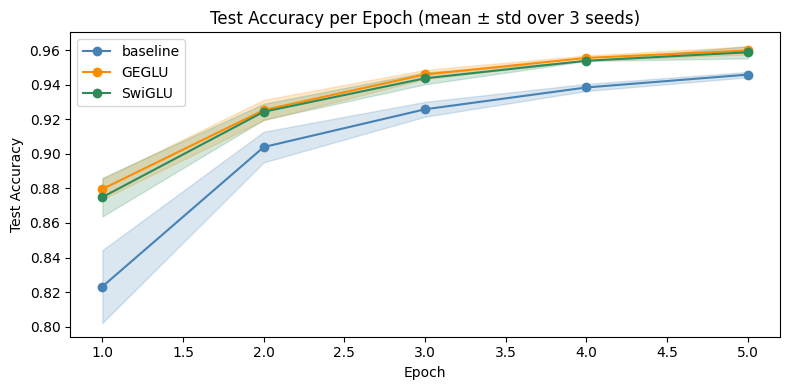

In [23]:
plt.figure(figsize=(8, 4))
for name, color in zip(runs, colors):
    accs = torch.tensor([r["test_accs"] for r in all_results[name]])  # (3, epochs)
    mean = accs.mean(dim=0)
    std = accs.std(dim=0)
    epochs = range(1, len(mean) + 1)
    plt.plot(epochs, mean, marker="o", label=name, color=color)
    plt.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy per Epoch (mean ± std over 3 seeds)")
plt.legend()
plt.tight_layout()
plt.savefig("test_accuracy_stability.png", dpi=150)
plt.show()

#### Discussion
- Both GLU variants clearly outperform baseline both on train loss and test accuracy. The difference is particularly pronounced in the beginning, where GLU manages ~0.06 higher accuracy after one epoch. This could be due to the gating mechanism improving gradient flow leading to faster convergence, though this is speculative.
- Performance between both GLU variants is roughly comparable, suggesting that for this task gating mechanism is more important than which of the two activation functions was used. An interesting additional control would be baseline, but with Swish activations.
- Theses difference are stable across three random seeds
- This gap could be more relevant for harder tasks/under harder compute constraints, since all conditions nearly saturate the benchmark pretty quickly.